In [104]:
import os
import pandas as pd
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st # for Cumulative Distribution Function in VdW score 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load the data (download pre_processing.csv from ".....")

In [105]:
df = pd.read_parquet('datasets/pre_processing.parquet')

In [106]:
df_capital = df[df['mun_istat'] == df['cap_mun_istat']].copy()

Keep data with listings over 11 years

In [107]:
# count number of years per id
obs_per_id = df.groupby(['mun_istat'])['year'].nunique()

# count how many ids have 1 year, 2 years, etc.
count_by_years = obs_per_id.value_counts().sort_index()

print(count_by_years)

year
1        2
2        1
3       21
4        5
5        1
7       38
8        7
9        6
10      21
11    7771
Name: count, dtype: int64


In [108]:
# keep only ids with listings over 11 years - balanced panel data
ids_eleven = obs_per_id[obs_per_id == 11].index

# filter the data
df = df[df['mun_istat'].isin(ids_eleven)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mun_istat                85481 non-null  object  
 1   year                     85481 non-null  int64   
 2   mun_name                 85481 non-null  object  
 3   mun_name_norm            85481 non-null  object  
 4   location                 85481 non-null  category
 5   region                   85481 non-null  object  
 6   prov                     85481 non-null  object  
 7   buy_min                  85481 non-null  float64 
 8   buy_max                  85481 non-null  float64 
 9   prov_istat               85481 non-null  object  
 10  population               85481 non-null  float64 
 11  surface                  85481 non-null  float64 
 12  median_income            85481 non-null  float64 
 13  changed                  85481 non-null  bool    
 14  suppressed 

Cumulative data per province (population, dwellings, tourism values)

In [109]:
sum_col = ['population', 'dwellings', 'surface', 'five_stars_count','four_stars_count','three_stars_count','two_stars_count','one_stars_count','holiday_dwelling_count','holiday_dwelling_beds','tot_count','tot_acc_beds','tot_beds','tot_arrivals_residents','tot_arrivals_foreigners','tot_arrivals','tot_nights_residents','tot_nights_foreigners','tot_nights']

for col in sum_col:
    df['prov_' + col] = df.groupby(['year', 'prov'], observed=True)[col].transform('sum')

Weighted averages per province (buy_min, buy_max, median_income)

In [110]:
# buy_min * dwellings
df['buy_min_fraction'] = (df['buy_min'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_min_wgt'] = df.groupby(['year','prov'], observed=True)['buy_min_fraction'].transform('sum')

# buy_max * dwellings
df['buy_max_fraction'] = (df['buy_max'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_max_wgt'] = df.groupby(['year','prov'], observed=True)['buy_max_fraction'].transform('sum')

# median_income * population
df['median_income_fraction'] = (df['median_income'] * df['population']) / df['prov_population']
df['prov_median_income_wgt'] = df.groupby(['year','prov'], observed=True)['median_income_fraction'].transform('sum')

# drop fraction cols
df = df.drop(columns = ['buy_min_fraction', 'buy_max_fraction', 'median_income_fraction'])

Immigration and emigration ratios

In [111]:
# total number of immigrants and emigrants (standardized per 100 inhabitants) - SEMI-ELASTICITY
df['prov_immigration'] = ((df['abroad_in'] + df['nation_in']) / df['population']) * 100

df['prov_emigration'] = ((df['abroad_out'] + df['nation_out']) / df['population']) * 100

Tourism indexes

In [112]:
# total number of hotel beds
hotel_col = [
    'prov_five_stars_count',
    'prov_four_stars_count',
    'prov_three_stars_count',
    'prov_two_stars_count',
    'prov_one_stars_count'
]

df['prov_hotel_count'] = df[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df = df.drop(columns = hotel_col)

# two variables are computed for a better overview of hotel presence in a municipality
# HOTEL PRESSURE ON TOURISM SECTOR - ratio between hotel beds (total beds - other accomodations bed) and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_hotel_beds'] = np.where(df['prov_tot_beds'] == 0, 0, ((df['prov_tot_beds'] - df['prov_tot_acc_beds']) / df['prov_tot_beds']) * 100)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_hotel_mun'] = ((df['prov_tot_beds'] - df['prov_tot_acc_beds']) / df['prov_population']) * 100

###

# three variables are computed for a better overview of holiday dwellings impact on the tourism sector and on municipalities
# STR PRESSURE ON TOURISM SECTOR - ratio between holiday dwellings bed and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_beds'] = np.where(df['prov_tot_beds'] == 0, 0, (df['prov_holiday_dwelling_beds'] / df['prov_tot_beds']) * 100) 

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_mun'] = (df['prov_holiday_dwelling_count'] / df['prov_dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_str_mun_beds'] = (df['prov_holiday_dwelling_beds'] / df['prov_population']) * 100

###

# measure the ratio between total arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_arrivals'] = (df['prov_tot_arrivals'] / df['prov_population']) * 100

# measure the ratio between total foreigner arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df['prov_ratio_arrivals_foreigners'] = (df['prov_tot_arrivals_foreigners'] / df['prov_population']) * 100

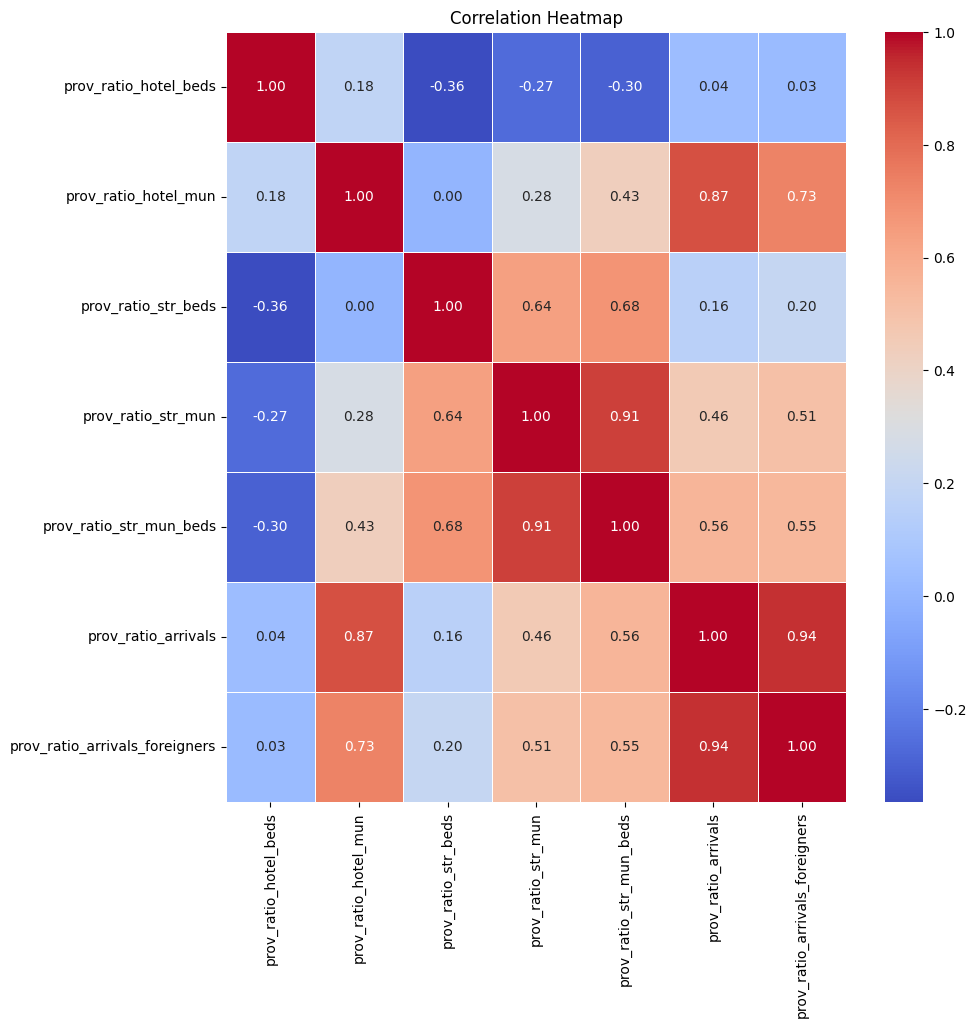

In [113]:
# correlation matrix
var_corr = [
    'prov_ratio_hotel_beds',
    'prov_ratio_hotel_mun',
    'prov_ratio_str_beds',
    'prov_ratio_str_mun',
    'prov_ratio_str_mun_beds',
    'prov_ratio_arrivals',
    'prov_ratio_arrivals_foreigners'
]

matrix = df[var_corr].corr()

plt.figure(figsize=(10,10))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [114]:
# compute Van der Waerden score as a tourist index - consider prov_ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'prov_ratio_hotel_mun',
    'prov_ratio_str_mun',
    'prov_ratio_str_mun_beds',
    'prov_ratio_arrivals',
    'prov_ratio_arrivals_foreigners'
]

for col in vars_tourism:
    df[col + '_vdw'] = van_der_waerden_score(df[col])

# composite index based on VdW scores (average value)
df['tourism_index_vdw'] = df[[v + '_vdw' for v in vars_tourism]].mean(axis=1)

# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_vdw'].min())
print("Maximum tourism score: ", df['tourism_index_vdw'].max())

Minimum tourism score:  2.2176598582157645
Maximum tourism score:  98.51781661636369


In [115]:
# Standardize
X = StandardScaler().fit_transform(df[vars_tourism])

# PCA with 1 component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)[:, 0]

# Variance explained
print("Variance explained by first component:", pca.explained_variance_ratio_[0])

# Shift to make positive
pc1_positive = pc1 - pc1.min() + 1e-6

# Scale 0–100
df['tourism_index_pca'] = 100 * (pc1_positive / pc1_positive.max())

# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_pca'].min())
print("Maximum tourism score: ", df['tourism_index_pca'].max())

Variance explained by first component: 0.7030094773454344
Minimum tourism score:  6.868940995342134e-06
Maximum tourism score:  100.0


Group by province

In [116]:
df_prov = df.groupby(['year','prov'], observed=True).agg({
    'location':'first',
    'region':'first',
    'prov_buy_min_wgt':'first',
    'prov_buy_max_wgt':'first',
    'prov_median_income_wgt':'first',
    'prov_population':'first',
    'prov_surface' : 'first',
    'prov_dwellings':'first',
    'prov_immigration':'first',
    'prov_emigration':'first',
    'prov_unemployment':'first',
    'over65':'first',
    'reg_age_avg':'first',
    'prov_ratio_hotel_beds':'first',
    'prov_ratio_hotel_mun':'first',
    'prov_ratio_str_beds':'first',
    'prov_ratio_str_mun':'first',
    'prov_ratio_str_mun_beds':'first',
    'prov_ratio_arrivals':'first',
    'prov_ratio_arrivals_foreigners':'first',
    'tourism_index_vdw':'first',
    'tourism_index_pca':'first',
    'tour_employed':'first',
    'real_gdp':'first',
    'nominal_gdp':'first',
    'life':'first',
    'interest_rate':'first'
}).reset_index()

Log transform

In [117]:
log_col = ['prov_buy_min_wgt','prov_buy_max_wgt','prov_population','prov_dwellings','prov_surface','prov_median_income_wgt','prov_immigration','prov_emigration','tourism_index_vdw','tourism_index_pca','real_gdp','nominal_gdp','tour_employed','reg_age_avg','over65','life','prov_unemployment','interest_rate',
           'prov_ratio_hotel_mun','prov_ratio_str_mun','prov_ratio_str_mun_beds','prov_ratio_arrivals','prov_ratio_arrivals_foreigners']

for col in log_col:
    df_prov['log_' + col] = np.log(df_prov[col] + 1e-6)  # add a small constant to avoid log(0)

Growth rates

In [118]:
diff_col = ['log_prov_buy_min_wgt','log_prov_buy_max_wgt','log_prov_population','log_prov_median_income_wgt','log_prov_immigration','log_prov_emigration','log_tourism_index_vdw','log_tourism_index_pca','log_real_gdp','log_nominal_gdp','log_tour_employed','log_reg_age_avg','log_over65','log_life','log_prov_unemployment','log_interest_rate',
            'log_prov_ratio_hotel_mun','log_prov_ratio_str_mun','log_prov_ratio_str_mun_beds','log_prov_ratio_arrivals','log_prov_ratio_arrivals_foreigners']

for col in diff_col:
    df_prov['d_' + col] = df_prov.groupby('prov')[col].diff()

Density

In [119]:
df_prov['prov_density'] = np.log(df_prov['prov_population'] / df_prov['prov_surface'])

Dummies

In [120]:
# covid dummy
df_prov['covid'] = np.where(df_prov['year'] < 2020, 0, 1)

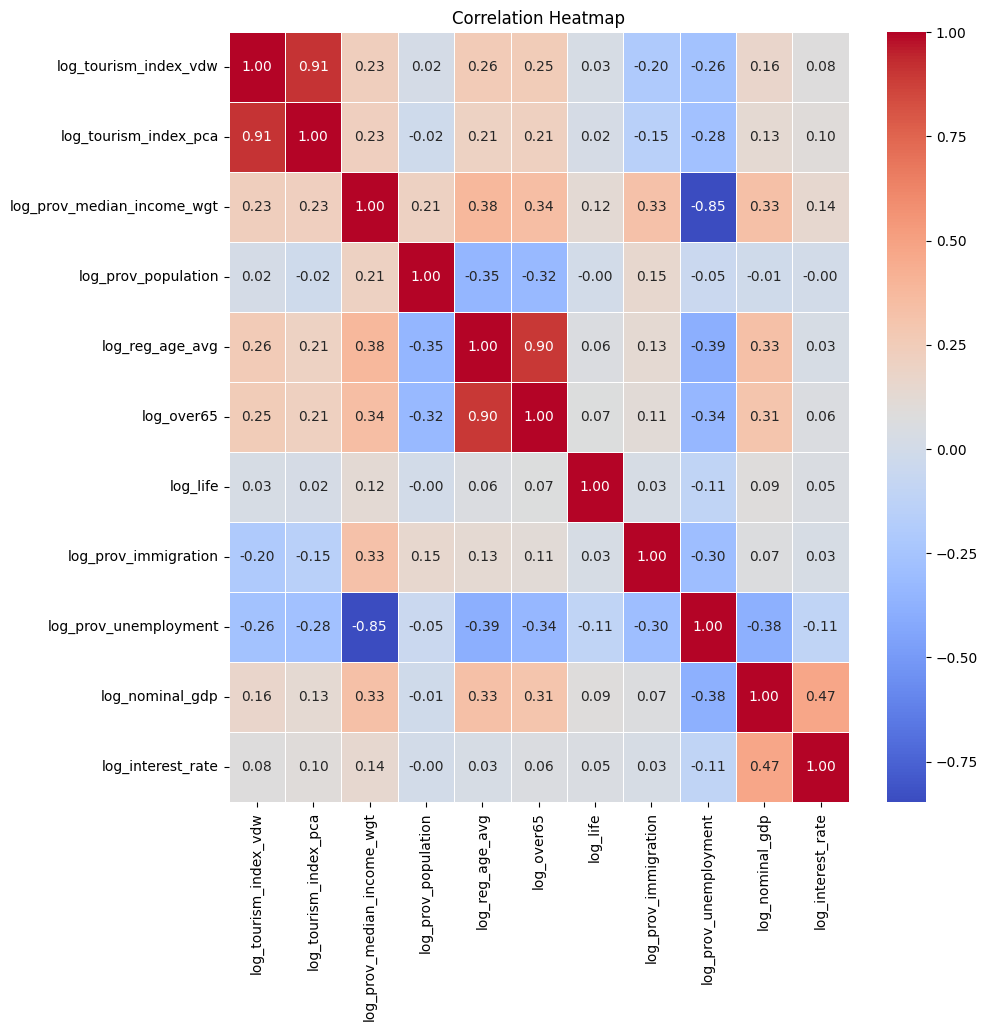

In [121]:
# correlation matrix
var_corr = [
    'log_tourism_index_vdw',
    'log_tourism_index_pca',
    'log_prov_median_income_wgt',
    'log_prov_population',
    'log_reg_age_avg',
    'log_over65',
    'log_life',
    'log_prov_immigration',
    'log_prov_unemployment',
    'log_nominal_gdp',
    'log_interest_rate'
]

matrix = df_prov[var_corr].corr()

plt.figure(figsize=(10,10))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Perform th same operations on df_capital

In [122]:
# total number of immigrants, emigrants, and net movements (standardized per 100 inhabitants) - SEMI-ELASTICITY
df_capital['prov_immigration'] = ((df_capital['abroad_in'] + df_capital['nation_in']) / df_capital['population']) * 100

df_capital['prov_emigration'] = ((df_capital['abroad_out'] + df_capital['nation_out']) / df_capital['population']) * 100

In [123]:
# total number of hotel beds
hotel_col = [
    'five_stars_count',
    'four_stars_count',
    'three_stars_count',
    'two_stars_count',
    'one_stars_count'
]

df_capital['hotel_count'] = df_capital[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df_capital = df_capital.drop(columns = hotel_col)

# two variables are computed for a better overview of hotel presence in a municipality
# HOTEL PRESSURE ON TOURISM SECTOR - ratio between hotel beds (total beds - other accomodations bed) and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_hotel_beds'] = np.where(df_capital['tot_beds'] == 0, 0, ((df_capital['tot_beds'] - df_capital['tot_acc_beds']) / df_capital['tot_beds']) * 100)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_hotel_mun'] = ((df_capital['tot_beds'] - df_capital['tot_acc_beds']) / df_capital['population']) * 100

###

# three variables are computed for a better overview of holiday dwellings impact on the tourism sector and on municipalities
# STR PRESSURE ON TOURISM SECTOR - ratio between holiday dwellings bed and total beds (per 100 beds) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_str_beds'] = np.where(df_capital['tot_beds'] == 0, 0, (df_capital['holiday_dwelling_beds'] / df_capital['tot_beds']) * 100) 

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_str_mun'] = (df_capital['holiday_dwelling_count'] / df_capital['dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_str_mun_beds'] = (df_capital['holiday_dwelling_beds'] / df_capital['population']) * 100

###

# measure the ratio between total arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_arrivals'] = (df_capital['tot_arrivals'] / df_capital['population']) * 100

# measure the ratio between total foreigner arrivals and population (per 100 inhabitants) - LOG-LEVEL (SEMI-ELASTICITY)
df_capital['ratio_arrivals_foreigners'] = (df_capital['tot_arrivals_foreigners'] / df_capital['population']) * 100

In [124]:
# compute Van der Waerden score as a tourist index - consider ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'ratio_hotel_mun',
    'ratio_str_mun',
    'ratio_str_mun_beds',
    'ratio_arrivals',
    'ratio_arrivals_foreigners'
]

for col in vars_tourism:
    df_capital[col + '_vdw'] = van_der_waerden_score(df_capital[col])

# composite index based on VdW scores (average value)
df_capital['tourism_index_vdw'] = df_capital[[v + '_vdw' for v in vars_tourism]].mean(axis=1)

# check minimum and maximum tourism score
print("Minimum tourism score: ", df_capital['tourism_index_vdw'].min())
print("Maximum tourism score: ", df_capital['tourism_index_vdw'].max())

Minimum tourism score:  0.4789430222956234
Maximum tourism score:  99.53757225433526


In [125]:
# Standardize
X = StandardScaler().fit_transform(df_capital[vars_tourism])

# PCA with 1 component
pca = PCA(n_components=1)
pc1 = pca.fit_transform(X)[:, 0]

# Variance explained
print("Variance explained by first component:", pca.explained_variance_ratio_[0])

# Shift to make positive
pc1_positive = pc1 - pc1.min() + 1e-6

# Scale 0–100
df_capital['tourism_index_pca'] = 100 * (pc1_positive / pc1_positive.max())

# check minimum and maximum tourism score
print("Minimum tourism score: ", df_capital['tourism_index_pca'].min())
print("Maximum tourism score: ", df_capital['tourism_index_pca'].max())

Variance explained by first component: 0.7293437019698639
Minimum tourism score:  4.579768563016754e-06
Maximum tourism score:  100.0


In [126]:
log_col = ['buy_min','buy_max','population','dwellings','median_income','prov_immigration','prov_emigration','tourism_index_vdw','tourism_index_pca','real_gdp','nominal_gdp','tour_employed','reg_age_avg','over65','life','prov_unemployment','interest_rate',
           'ratio_hotel_mun','ratio_str_mun','ratio_str_mun_beds','ratio_arrivals','ratio_arrivals_foreigners']

(df_capital[log_col] == 0).sum()

buy_min                       0
buy_max                       0
population                    0
dwellings                     0
median_income                 0
prov_immigration              0
prov_emigration               0
tourism_index_vdw             0
tourism_index_pca             0
real_gdp                      0
nominal_gdp                   0
tour_employed                 0
reg_age_avg                   0
over65                        0
life                          0
prov_unemployment             0
interest_rate                 0
ratio_hotel_mun               2
ratio_str_mun                18
ratio_str_mun_beds           18
ratio_arrivals                1
ratio_arrivals_foreigners     1
dtype: int64

In [127]:
log_col = ['buy_min','buy_max','population','dwellings','median_income','prov_immigration','prov_emigration','tourism_index_vdw','tourism_index_pca','real_gdp','nominal_gdp','tour_employed','reg_age_avg','over65','life','prov_unemployment','interest_rate',
           'ratio_hotel_mun','ratio_str_mun','ratio_str_mun_beds','ratio_arrivals','ratio_arrivals_foreigners']

for col in log_col:
    df_capital['log_' + col] = np.log(df_capital[col] + 1e-6)

diff_col = ['log_buy_min','log_buy_max','log_population','log_median_income','log_prov_immigration','log_prov_emigration','log_tourism_index_vdw','log_tourism_index_pca','log_real_gdp','log_nominal_gdp','log_tour_employed','log_reg_age_avg','log_over65','log_life','log_prov_unemployment','log_interest_rate',
            'log_ratio_hotel_mun','log_ratio_str_mun','log_ratio_str_mun_beds','log_ratio_arrivals','log_ratio_arrivals_foreigners']

for col in diff_col:
    df_capital['d_' + col] = df_capital.groupby('mun_istat')[col].diff()

In [128]:
df_capital['prov_density'] = np.log(df_capital['population'] / df_capital['surface'])

In [129]:
# covid dummy
df_capital['covid'] = np.where(df_capital['year'] < 2020, 0, 1)

In [130]:
col = ['mun_istat','year','location','region','prov','log_buy_min','log_buy_max','log_population','log_median_income','log_prov_immigration','log_prov_emigration','log_tourism_index_vdw','log_tourism_index_pca','log_real_gdp','log_nominal_gdp','log_tour_employed','log_reg_age_avg','log_over65','log_life','log_prov_unemployment','log_interest_rate',
       'd_log_buy_min','d_log_buy_max','d_log_population','d_log_median_income','d_log_prov_immigration','d_log_prov_emigration','d_log_tourism_index_vdw','d_log_tourism_index_pca','d_log_real_gdp','d_log_nominal_gdp','d_log_tour_employed','d_log_reg_age_avg','d_log_over65','d_log_life','d_log_prov_unemployment','d_log_interest_rate',
       'log_ratio_hotel_mun','log_ratio_str_mun','log_ratio_str_mun_beds','log_ratio_arrivals','log_ratio_arrivals_foreigners','d_log_ratio_hotel_mun','d_log_ratio_str_mun','d_log_ratio_str_mun_beds','d_log_ratio_arrivals','d_log_ratio_arrivals_foreigners','covid']

df_capital = df_capital[col]

Save the data

In [131]:
df_prov.to_csv('datasets/model.csv', index = False)
df_capital.to_csv('datasets/model_capital.csv', index = False)